# Primary dataset cleaning & EDA

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1. Merging

In [4]:
DATA_DIR = "data/IEEE-CIS/ieee-fraud-detection/"

In [5]:
train_tx = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
train_id = pd.read_csv(f'{DATA_DIR}/train_identity.csv')

df = train_tx.merge(train_id, on='TransactionID', how='left')

df = df.copy()

## 2. EDA & cleaning

In [6]:
print(df.shape)
print(df.dtypes)
df.head()

(590540, 434)
TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
id_36              object
id_37              object
id_38              object
DeviceType         object
DeviceInfo         object
Length: 434, dtype: object


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [7]:
print(df['TransactionDT'].min())
print(df['TransactionDT'].max())
print((f"Time range: {(df['TransactionDT'].max() - df['TransactionDT'].min()) / 86400:.2f} days"))

86400
15811131
Time range: 182.00 days


In [8]:
duplicate_ids = df['TransactionID'].duplicated().sum()
print(f"Number of duplicate TransactionIDs: {duplicate_ids}")
print("Full row duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicate TransactionIDs: 0
Full row duplicates: 0


isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud rate: 0.0350


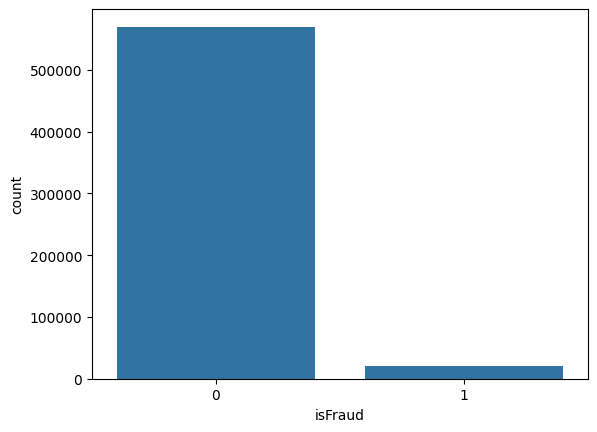

In [9]:
sns.countplot(x='isFraud', data=df)
print(df['isFraud'].value_counts())
print(f"Fraud rate: {df['isFraud'].mean():.4f}")

<Axes: xlabel='isFraud', ylabel='TransactionAmt_log'>

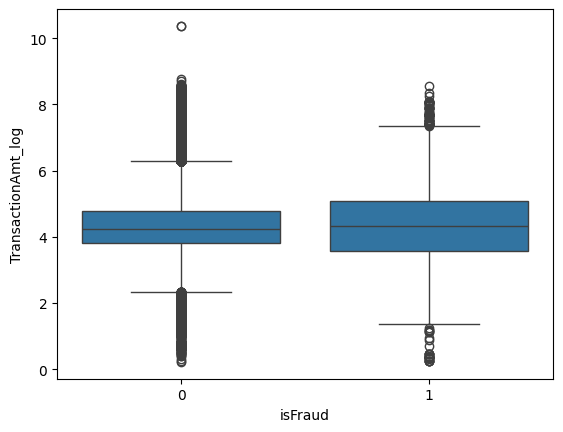

In [10]:
df.groupby('isFraud')['TransactionAmt'].describe()

# log scale because of heavy skew
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
sns.boxplot(x='isFraud', y='TransactionAmt_log', data=df)

<Axes: xlabel='day'>

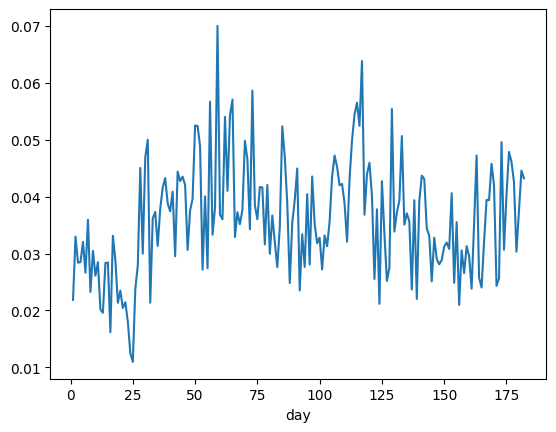

In [11]:
df['day'] = df['TransactionDT'] // 86400
fraud_by_day = df.groupby('day')['isFraud'].mean()
fraud_by_day.plot()

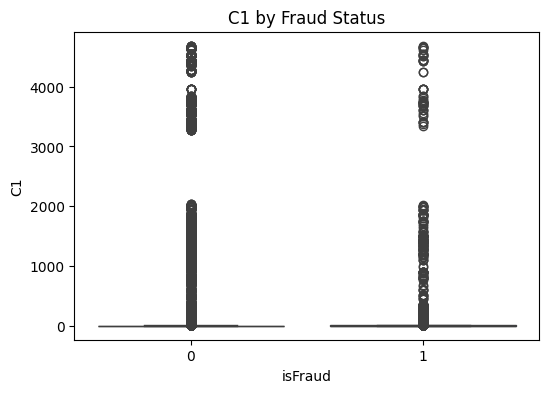

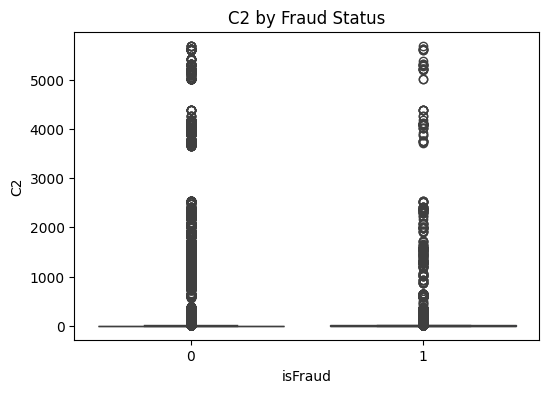

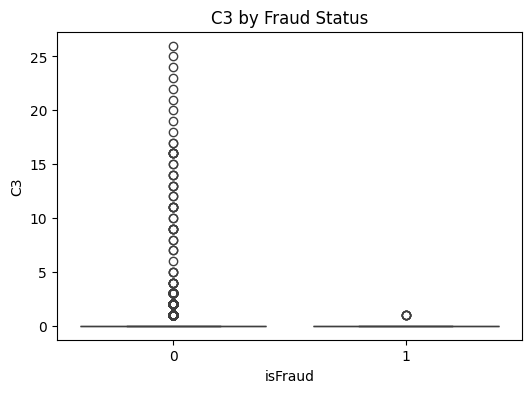

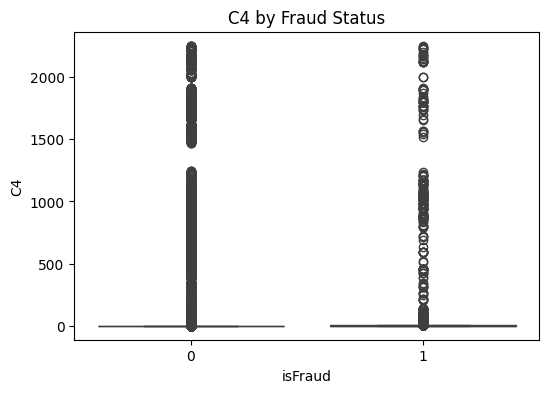

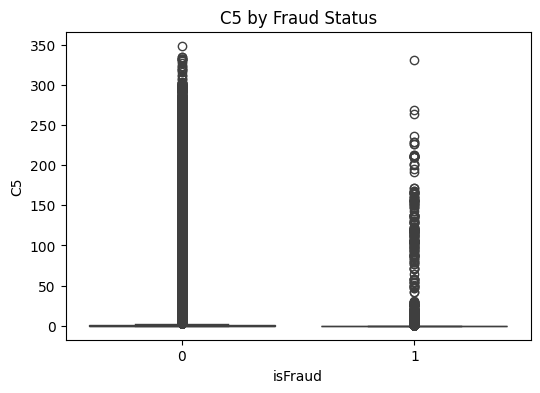

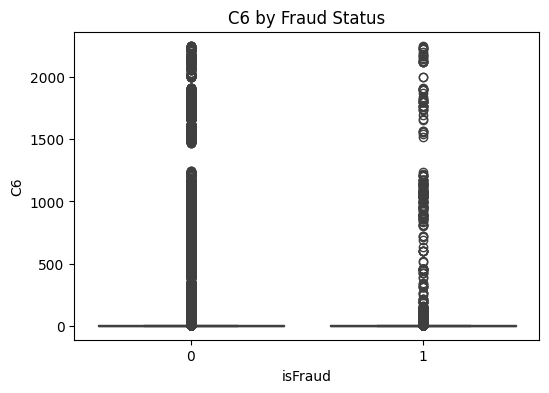

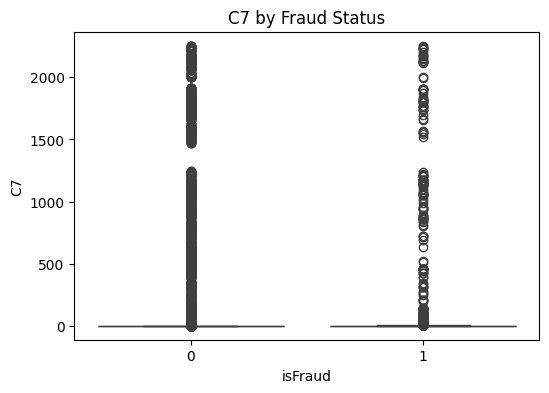

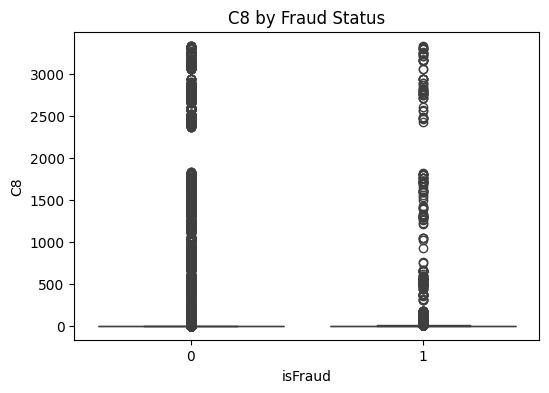

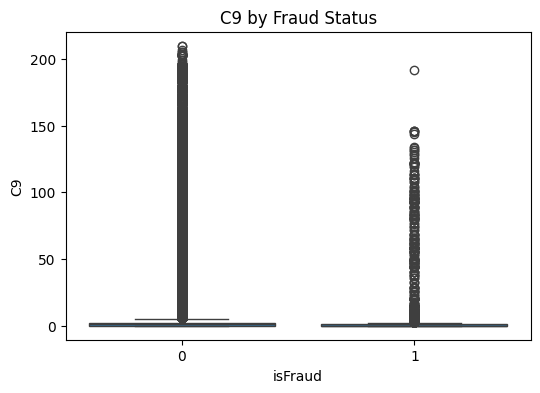

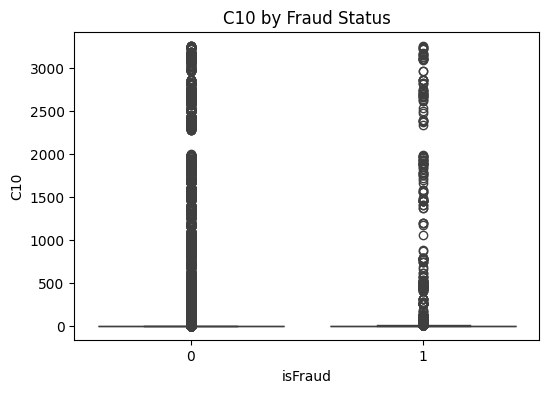

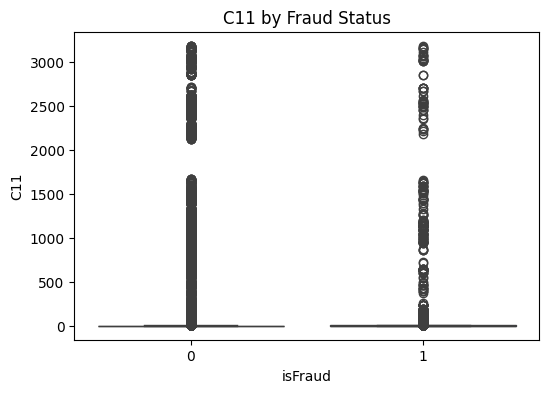

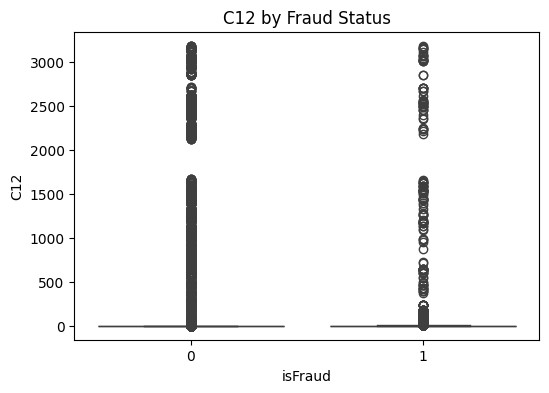

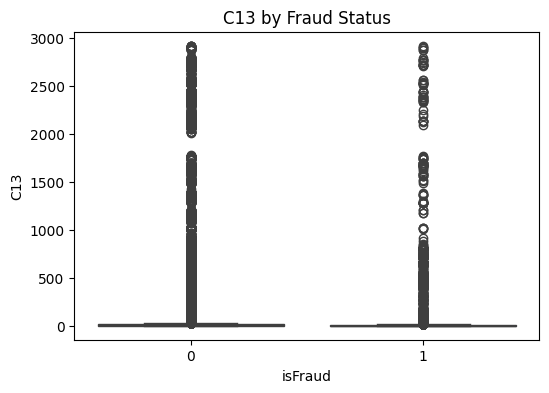

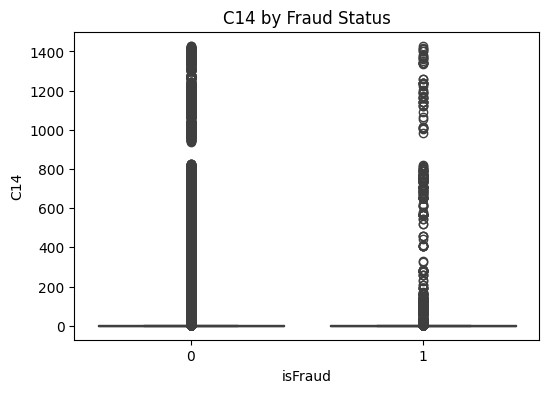

In [12]:
# distribution of C1-C14 by fraud status
for col in [f'C{i}' for i in range(1, 15)]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='isFraud', y=col, data=df)
    plt.title(f'{col} by Fraud Status')
    plt.show()

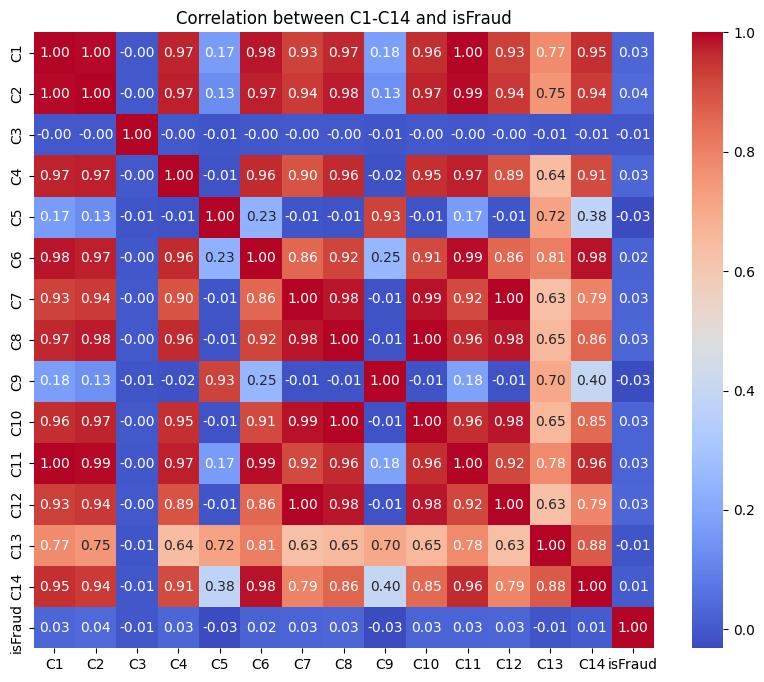

In [13]:
# check correlation between C1-C14 and isFraud
corr = df[[f'C{i}' for i in range(1, 15)] + ['isFraud']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between C1-C14 and isFraud')
plt.show()

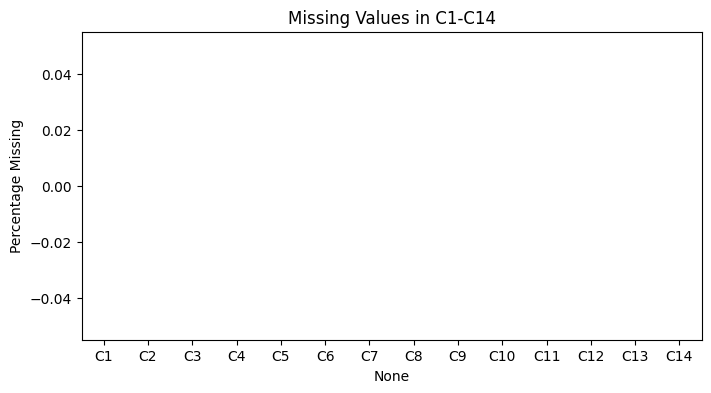

In [14]:
# % missing in C columns, show as chart
c_cols = [f'C{i}' for i in range(1, 15)]
missing_c = df[c_cols].isnull().mean() * 100
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_c.index, y=missing_c.values)
plt.title('Missing Values in C1-C14')
plt.ylabel('Percentage Missing')
plt.show()

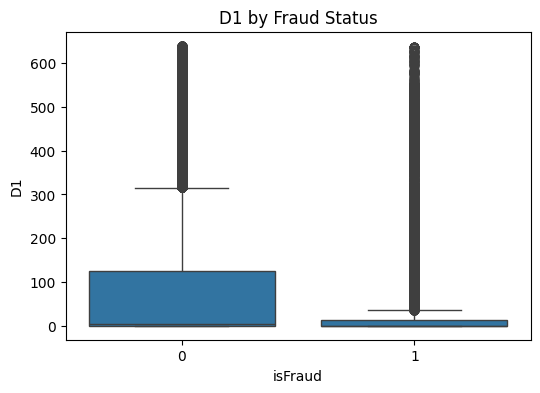

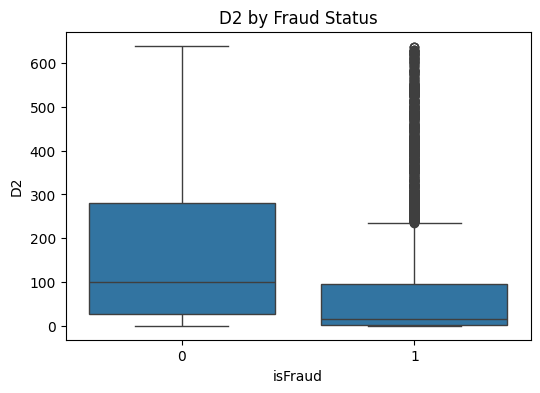

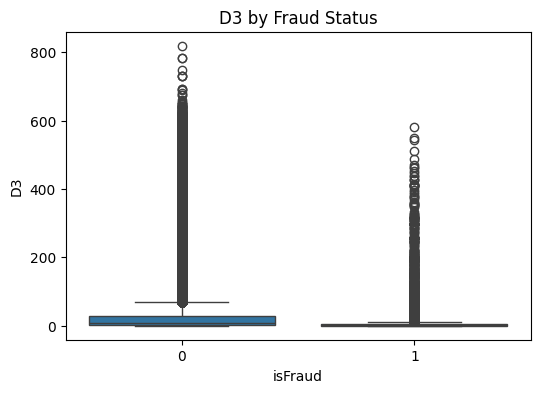

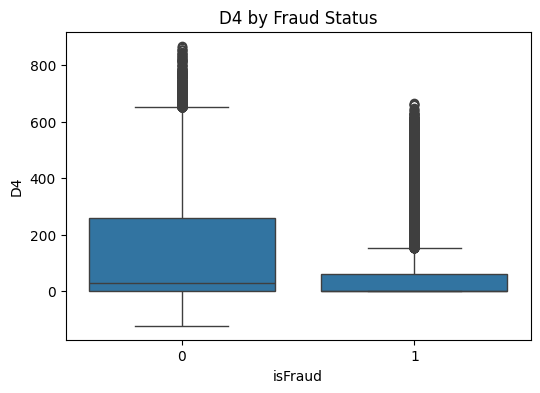

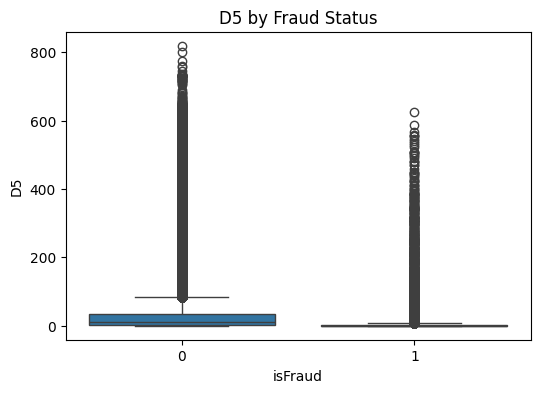

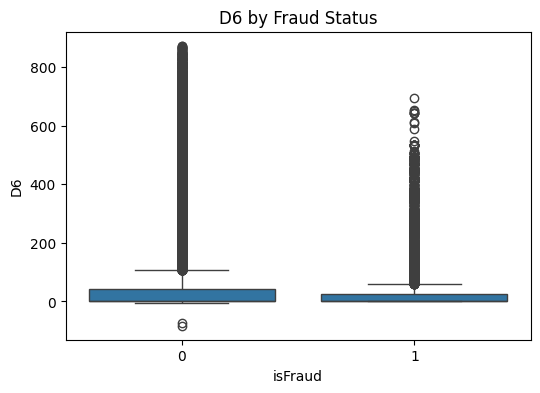

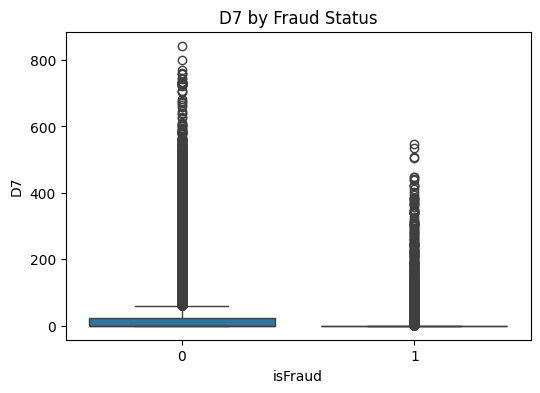

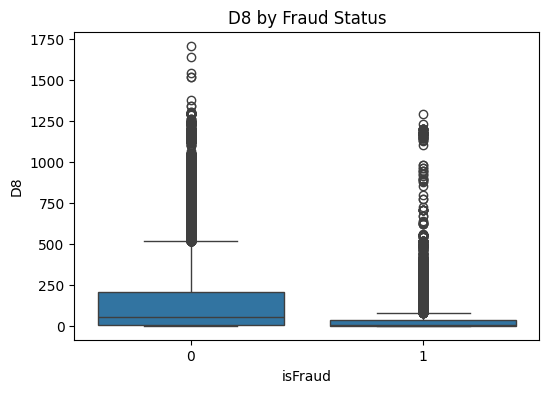

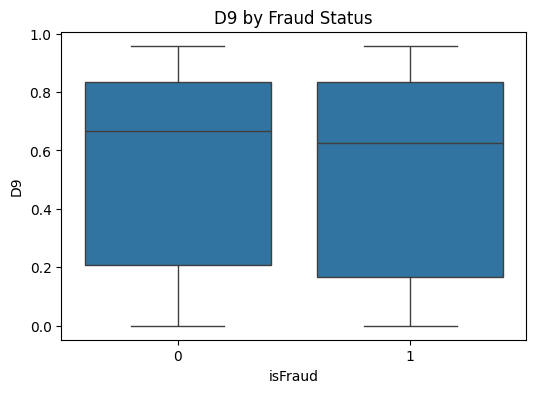

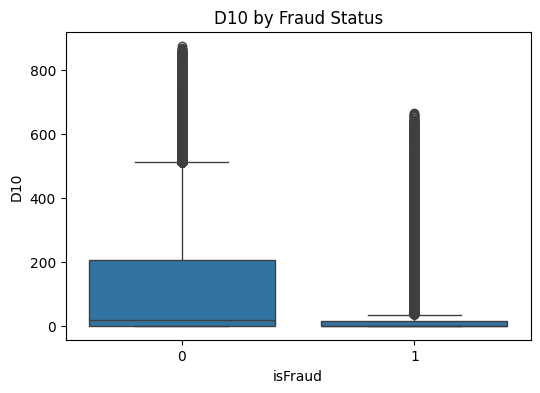

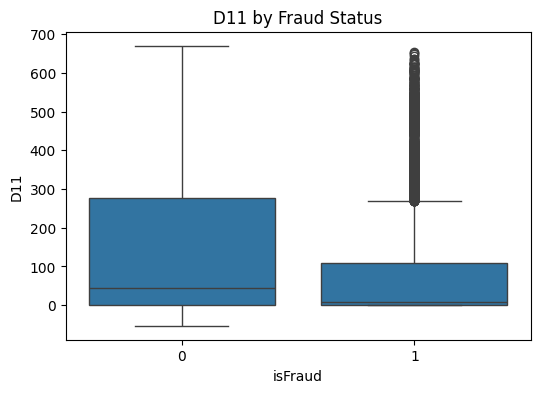

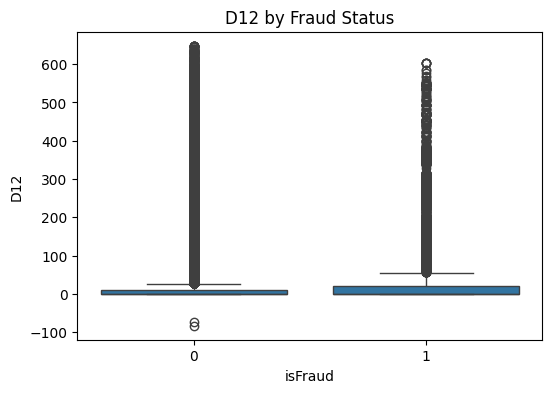

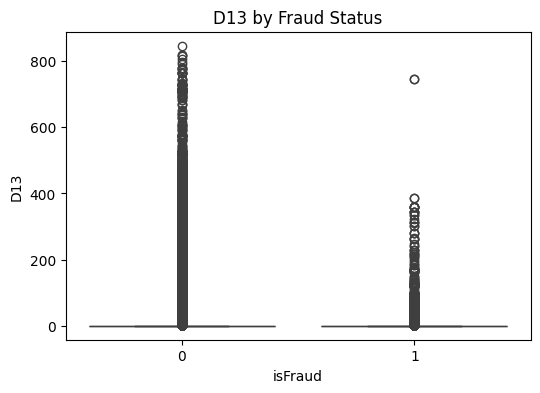

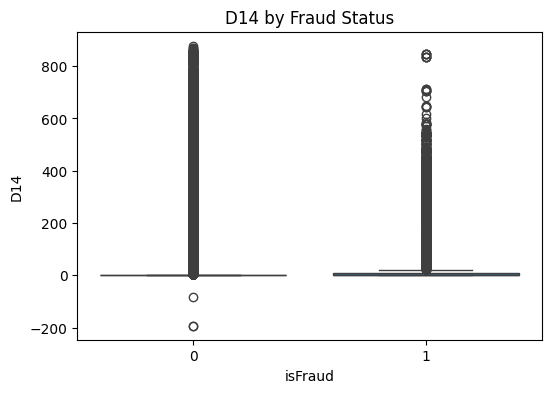

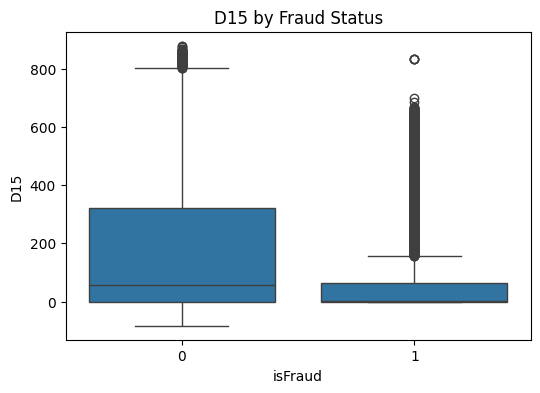

In [15]:
# Distribution of D1-D15 (time-based features) by fraud status
for col in [f'D{i}' for i in range(1, 16)]:
    try:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x='isFraud', y=col, data=df)
        plt.title(f'{col} by Fraud Status')
        plt.show()
    except:
        print(f"{col} not found in dataframe")

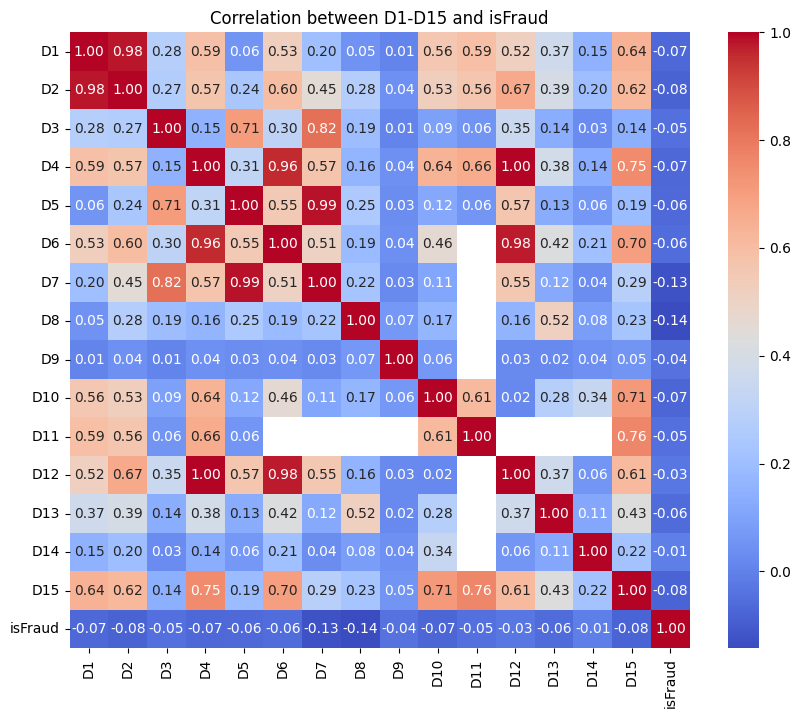

In [16]:
# Correlation of D1-D15 with isFraud
corr_d = df[[f'D{i}' for i in range(1, 16)] + ['isFraud']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_d, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between D1-D15 and isFraud')
plt.show()

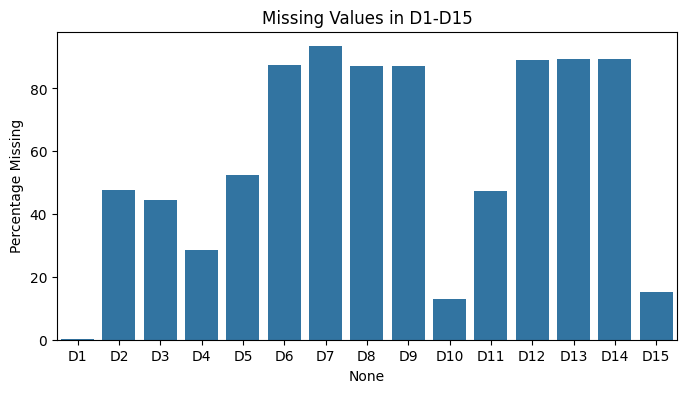

In [17]:
# % missing in D columns, show as chart
d_cols = [f'D{i}' for i in range(1, 16)]
missing_d = df[d_cols].isnull().mean() * 100
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_d.index, y=missing_d.values)
plt.title('Missing Values in D1-D15')
plt.ylabel('Percentage Missing')
plt.show()

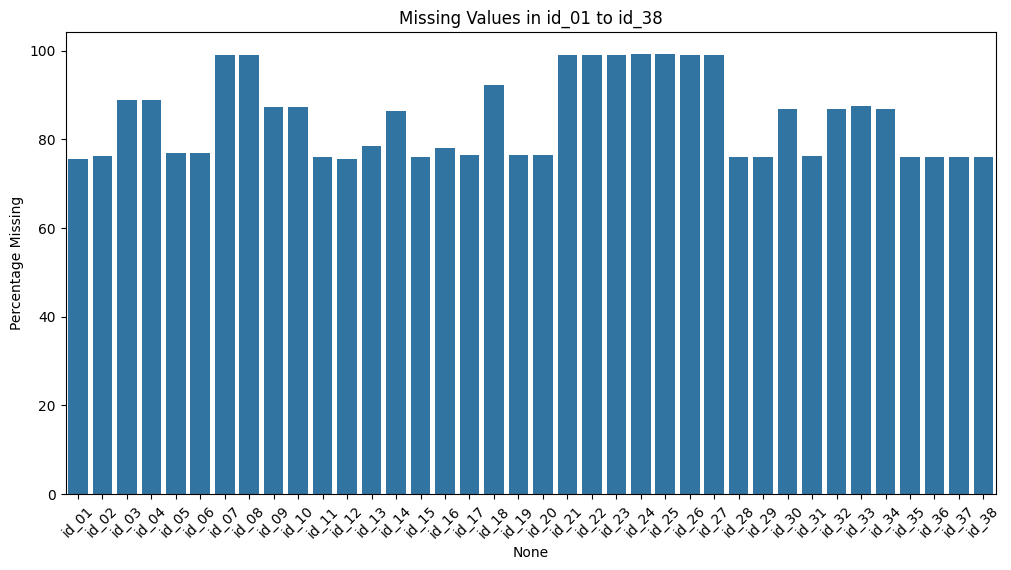

In [18]:
# % missing in columns id_01 to id_38, show the missing % as a chart
id_cols = [f'id_{i:02d}' for i in range(1, 39)]
missing_id = df[id_cols].isnull().mean() * 100
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_id.index, y=missing_id.values)
plt.title('Missing Values in id_01 to id_38')
plt.ylabel('Percentage Missing')
plt.xticks(rotation=45)
plt.show()

In [19]:
# drop id columns with >99% missing, drop to df_clean
cols_to_drop = missing_id[missing_id > 99].index.tolist()
print(f"Dropping columns with >99% missing: {cols_to_drop}")
df_clean = df.drop(columns=cols_to_drop)

Dropping columns with >99% missing: ['id_07', 'id_08', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27']


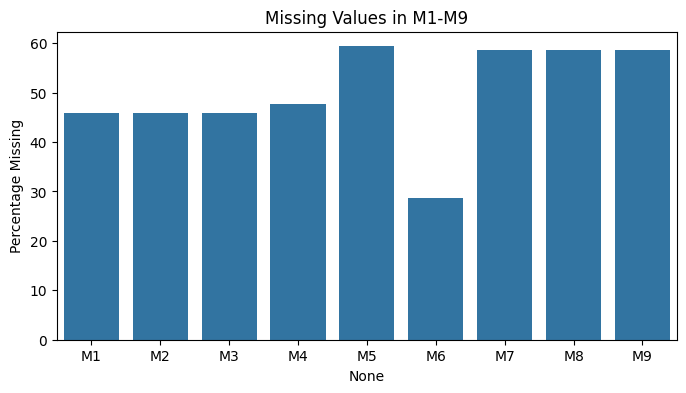

In [20]:
# % missing in M columns, show as chart
m_cols = [f'M{i}' for i in range(1, 10)]
missing_m = df[m_cols].isnull().mean() * 100
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_m.index, y=missing_m.values)
plt.title('Missing Values in M1-M9')
plt.ylabel('Percentage Missing')
plt.show()

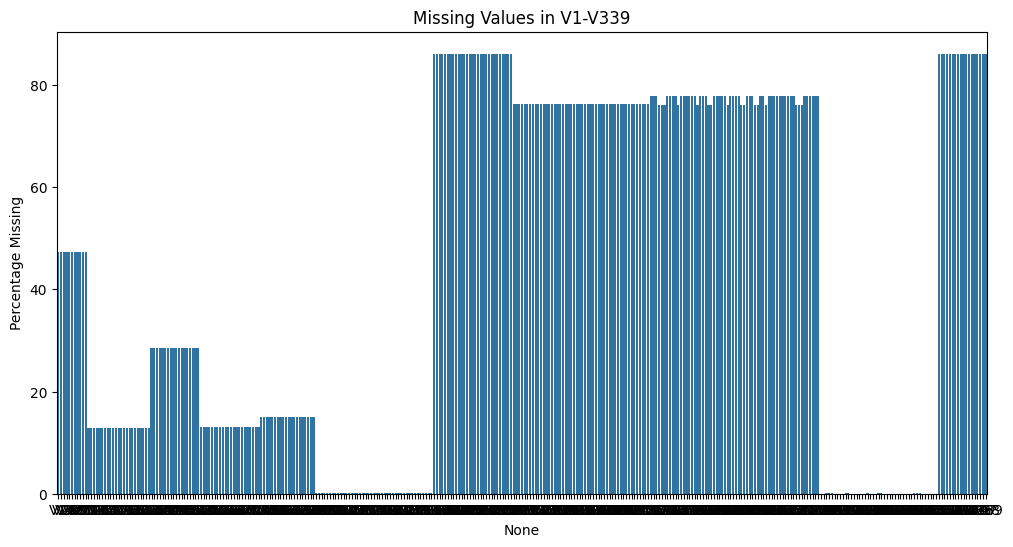

In [21]:
# % missing of V columns, show as chart
v_cols = [f'V{i}' for i in range(1, 340)]
missing_v = df[v_cols].isnull().mean() * 100
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_v.index, y=missing_v.values)
plt.title('Missing Values in V1-V339')
plt.ylabel('Percentage Missing')
plt.show()

In [22]:
# correlation of V columns within themselves, only list those with correlation >0.9 or <-0.9
v_corr = df[v_cols].corr()
high_corr = v_corr[(v_corr > 0.9) | (v_corr < -0.9)]
high_corr_pairs = []
for i in range(len(high_corr.columns)):
    for j in range(i + 1, len(high_corr.columns)):
        if not np.isnan(high_corr.iloc[i, j]):
            high_corr_pairs.append((high_corr.columns[i], high_corr.columns[j], high_corr.iloc[i, j]))
print("Highly correlated V columns (|corr| > 0.9):")
for col1, col2, corr_value in high_corr_pairs:
    print(f"{col1} and {col2}: correlation = {corr_value:.2f}")

Highly correlated V columns (|corr| > 0.9):
V4 and V5: correlation = 0.92
V10 and V11: correlation = 0.97
V10 and V90: correlation = 0.91
V12 and V13: correlation = 0.93
V15 and V16: correlation = 0.99
V15 and V31: correlation = 0.92
V15 and V33: correlation = 0.96
V15 and V34: correlation = 0.92
V15 and V50: correlation = 0.95
V15 and V51: correlation = 0.92
V15 and V57: correlation = 0.96
V15 and V58: correlation = 0.93
V15 and V71: correlation = 0.91
V15 and V73: correlation = 0.91
V15 and V79: correlation = 0.93
V15 and V92: correlation = 0.91
V15 and V94: correlation = 0.95
V16 and V31: correlation = 0.90
V16 and V32: correlation = 0.91
V16 and V33: correlation = 0.94
V16 and V34: correlation = 0.93
V16 and V50: correlation = 0.93
V16 and V51: correlation = 0.90
V16 and V57: correlation = 0.94
V16 and V58: correlation = 0.91
V16 and V79: correlation = 0.91
V16 and V94: correlation = 0.93
V17 and V18: correlation = 0.99
V17 and V21: correlation = 0.95
V17 and V22: correlation = 0.9

In [23]:
# how many pairs of V columns have correlation >0.99 or <-0.99
v_corr = df[v_cols].corr()
high_corr_99 = v_corr[(v_corr > 0.99) | (v_corr < -0.99)]
high_corr_pairs_99 = []
for i in range(len(high_corr_99.columns)):
    for j in range(i + 1, len(high_corr_99.columns)):
        if not np.isnan(high_corr_99.iloc[i, j]):
            high_corr_pairs_99.append((high_corr_99.columns[i], high_corr_99.columns[j], high_corr_99.iloc[i, j]))
print(f"Number of V column pairs with |correlation| > 0.99: {len(high_corr_pairs_99)}")

Number of V column pairs with |correlation| > 0.99: 139


In [24]:
# of the >0.99 correlated pairs, choose one column to drop from each pair (the one with more missing values), drop to df_clean
cols_to_drop_corr = set()
for col1, col2, corr_value in high_corr_pairs_99:
    missing_col1 = df[col1].isnull().mean()
    missing_col2 = df[col2].isnull().mean()
    if missing_col1 > missing_col2:
        cols_to_drop_corr.add(col1)
    else:
        cols_to_drop_corr.add(col2)
print(f"Columns to drop due to high correlation: {cols_to_drop_corr}")
df_clean = df_clean.drop(columns=cols_to_drop_corr)

Columns to drop due to high correlation: {'V322', 'V97', 'V231', 'V213', 'V269', 'V167', 'V318', 'V323', 'V18', 'V103', 'V333', 'V126', 'V177', 'V95', 'V179', 'V316', 'V330', 'V182', 'V332', 'V293', 'V296', 'V295', 'V233', 'V232', 'V317', 'V324', 'V101', 'V331', 'V134', 'V329', 'V132', 'V164', 'V276', 'V102', 'V211', 'V133'}


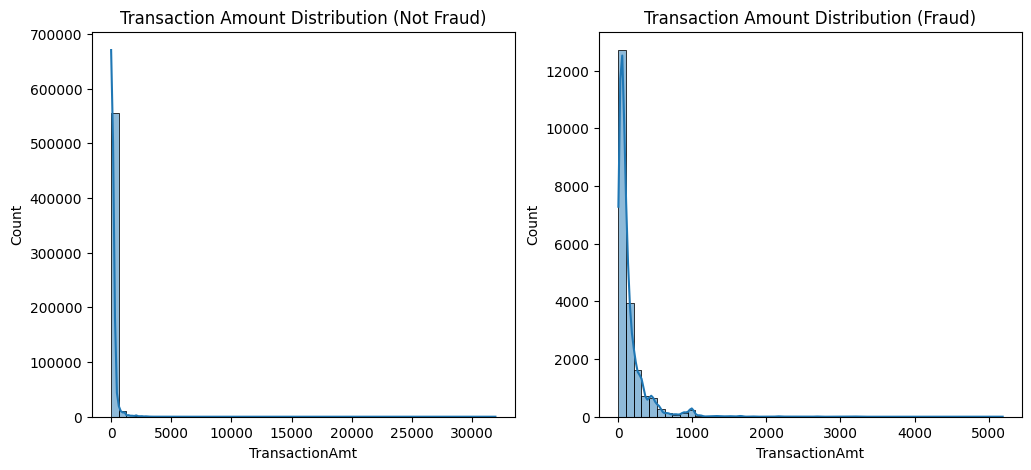

In [25]:
# histogram distribution of TransactionAmt, 2 graphs by fraud status
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[df['isFraud'] == 0]['TransactionAmt'], bins=50, kde=True)
plt.title('Transaction Amount Distribution (Not Fraud)')
plt.subplot(1, 2, 2)
sns.histplot(df[df['isFraud'] == 1]['TransactionAmt'], bins=50, kde=True)
plt.title('Transaction Amount Distribution (Fraud)')
plt.show()

In [26]:
# list counts of TransactionAmt by fraud status, split into categories of integers, round decimals e.g. 10.10, and odd decimals e.g. 10.11
df['TransactionAmt_cat'] = df['TransactionAmt'].apply(lambda x: 'integer' if x.is_integer() else ('round_decimal' if round(x, 2) == round(x, 0) + 0.10 else 'odd_decimal'))
transaction_amt_counts = df.groupby(['isFraud', 'TransactionAmt_cat']).size().unstack(fill_value=0)
print(transaction_amt_counts)

# % of categories by fraud status
transaction_amt_pct = transaction_amt_counts.div(transaction_amt_counts.sum(axis=1), axis=0) * 100
print(transaction_amt_pct)

TransactionAmt_cat  integer  odd_decimal  round_decimal
isFraud                                                
0                    294131       274854            892
1                     10882         9707             74
TransactionAmt_cat    integer  odd_decimal  round_decimal
isFraud                                                  
0                   51.613067    48.230408       0.156525
1                   52.664182    46.977690       0.358128


In [27]:
# save df_clean to csv
df_clean.to_csv('data/IEEE-CIS/df_clean.csv', index=False)